In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

from price_model.data.loaders import load_panel
from price_model.features.pipeline import build_feature_matrix, drop_warmup_rows

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

FEATURES = [
    "momentum_12_1",
    "momentum_756",
    "return_1d",
    "vol_ewm_20",
    "distance_52w_high",
    "log_dollar_volume",
]

# --- Regime-confined window ---
# Train 2022-10-10 -> 2024-11-30 (single refit), embargo gap, test 2025-01-01 -> 2026-05-22.
TRAIN_START = pd.Timestamp("2022-10-10")
TRAIN_END = pd.Timestamp("2024-11-30")
TEST_START = pd.Timestamp("2025-01-01")
TEST_END = pd.Timestamp("2026-05-22") # match the 348 days from the main analysis


def build_regression_frame() -> pd.DataFrame:
    """Regime-confined regression dataset.

    Full price history is loaded so the ~3yr momentum_756 warmup is satisfied, then
    the frame is sliced to the post-2022-10 deployment regime.
    """
    raw = load_panel(universe="sp500_pit", start="2017-01-01", pit_filter=True)
    matrix = (
        build_feature_matrix(raw, FEATURES, normalize_kind="rank", target_horizon=21)
        .pipe(drop_warmup_rows, FEATURES)
        .sort(["ticker", "date"])
    )
    df = matrix.to_pandas()
    df["date"] = pd.to_datetime(df["date"])
    df = df[df["date"] >= TRAIN_START]  # confine to the deployment regime
    return df.dropna(subset=FEATURES + ["y"]).reset_index(drop=True)


def regime_split(df: pd.DataFrame, date_col: str = "date") -> tuple[pd.DataFrame, pd.DataFrame]:
    """Single regime-confined train/test split.
    """
    train_df = df[df[date_col] <= TRAIN_END]
    test_df = df[(df[date_col] >= TEST_START) & (df[date_col] <= TEST_END)]
    return train_df, test_df


def _stride_dates(frame: pd.DataFrame, stride: int, date_col: str = "date") -> pd.DataFrame:
    """Keep every `stride`-th unique date (non-overlapping 21-day cadence)."""
    if stride <= 1:
        return frame
    keep = set(np.sort(frame[date_col].unique())[::stride])
    return frame[frame[date_col].isin(keep)]


def study_linear_regression_assumptions(
    df: pd.DataFrame,
    feature_cols: list[str] | None = None,
    test_stride: int = 1,
) -> None:
    """Fit the pooled OLS on the FULL daily train block, then inspect assumptions.

    The fit ALWAYS uses every daily (date, ticker) row in the train block — this is
    the headline coefficient (OLS is unbiased despite the 21-day overlap). Only the
    EVALUATION cadence changes: `test_stride=21` subsamples the test set to every
    21st date, so residuals are on independent, non-overlapping 21-day bets — exactly
    the headline's "fit daily, act every 21 days" logic. The beta is identical for
    any test_stride; only the residual diagnostics (DW / R^2 / normality) change.
    """
    feature_cols = feature_cols or FEATURES
    train_df, test_df = regime_split(df)  # fit on the full daily train block
    test_df = _stride_dates(test_df, test_stride)  # evaluate on (optionally) non-overlapping test
    X_train = train_df[feature_cols].astype(float)
    y_train = train_df["y"].astype(float)
    X_test = test_df[feature_cols].astype(float)
    y_test = test_df["y"].astype(float)

    model = LinearRegression()
    model.fit(X_train, y_train)

    # --- the linear map: ONE beta (k=6) + ONE scalar alpha, shared across all rows ---
    print("Pooled OLS:  y_hat = alpha + X @ beta   (fit on the full DAILY train block)")
    print(f"  beta.shape = {model.coef_.shape}   (one slope per feature)")
    for f, c in zip(feature_cols, model.coef_, strict=True):
        print(f"    {f:18s} {c:+.5f}")
    print(f"  alpha (intercept, scalar) = {model.intercept_:+.6f}")
    print(
        f"  X_train.shape = {X_train.shape}  (daily)   test rows = {len(test_df)}  "
        f"test dates = {test_df['date'].nunique()}  (test_stride={test_stride})"
    )
    print()

    fitted = model.predict(X_test)
    residuals = y_test - fitted

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    axes[0, 0].scatter(fitted, residuals, alpha=0.45)
    axes[0, 0].axhline(0, color="red", linestyle="--", linewidth=1)
    axes[0, 0].set_xlabel("Fitted values")
    axes[0, 0].set_ylabel("Residuals")
    axes[0, 0].set_title("Residuals vs fitted")

    sns.histplot(residuals, bins=80, kde=True, ax=axes[0, 1])
    axes[0, 1].set_xlabel("Residuals")
    axes[0, 1].set_ylabel("Density")
    axes[0, 1].set_title("Residual distribution (80 bins)")

    stats.probplot(residuals, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title("Q-Q plot of residuals")

    axes[1, 1].scatter(fitted, np.sqrt(np.abs(residuals)), alpha=0.45)
    axes[1, 1].set_xlabel("Fitted values")
    axes[1, 1].set_ylabel("sqrt(|Residuals|)")
    axes[1, 1].set_title("Homoscedasticity check")

    plt.tight_layout()
    plt.show()

    dw_stat = np.sum(np.diff(residuals) ** 2) / np.sum(residuals**2)
    skewness = stats.skew(residuals)
    kurtosis = stats.kurtosis(residuals, fisher=False)

    cadence = "NON-overlapping test (~16 independent 21-day bets)" if test_stride > 1 else "daily/overlapping test"
    print(f"Linear regression assumption study (fit on daily train; eval = {cadence})")
    print(f"Rows used (regime): {len(df)}")
    print(f"Test-set R^2: {model.score(X_test, y_test):.4f}")
    print(f"Durbin-Watson statistic: {dw_stat:.4f}")
    print(f"Residual skewness: {skewness:.4f}")
    print(f"Residual kurtosis: {kurtosis:.4f}")

    if 1.5 < dw_stat < 2.5:
        print("Independence: no strong autocorrelation signal is evident.")
    else:
        print("Independence: residuals show autocorrelation (expected — 21-day overlap).")


$CA: possibly delisted; no price data found  (1d 2017-01-01 -> 2026-07-31) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['CA']: possibly delisted; no price data found  (1d 2017-01-01 -> 2026-07-31) (Yahoo error = "No data found, symbol may be delisted")
$CA: possibly delisted; no price data found  (1d 2017-01-01 -> 2026-07-31) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['CA']: possibly delisted; no price data found  (1d 2017-01-01 -> 2026-07-31) (Yahoo error = "No data found, symbol may be delisted")
$CA: possibly delisted; no price data found  (1d 2017-01-01 -> 2026-07-31) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['CA']: possibly delisted; no price data found  (1d 2017-01-01 -> 2026-07-31) (Yahoo error = "No data found, symbol may be delisted")
yfinance returned no data for CA after 3 attempts
No data for CA
$CTRA: possibly delisted; no price data found  (1d 2017-01-01 -> 2026-07-31) (Ya

Pooled OLS:  y_hat = alpha + X @ beta   (fit on the full DAILY train block)
  beta.shape = (6,)   (one slope per feature)
    momentum_12_1      +0.00428
    momentum_756       +0.00269
    return_1d          -0.00217
    vol_ewm_20         +0.00593
    distance_52w_high  -0.00125
    log_dollar_volume  +0.00403
  alpha (intercept, scalar) = -0.006516
  X_train.shape = (236695, 6)  (daily)   test rows = 165136  test dates = 369  (test_stride=1)



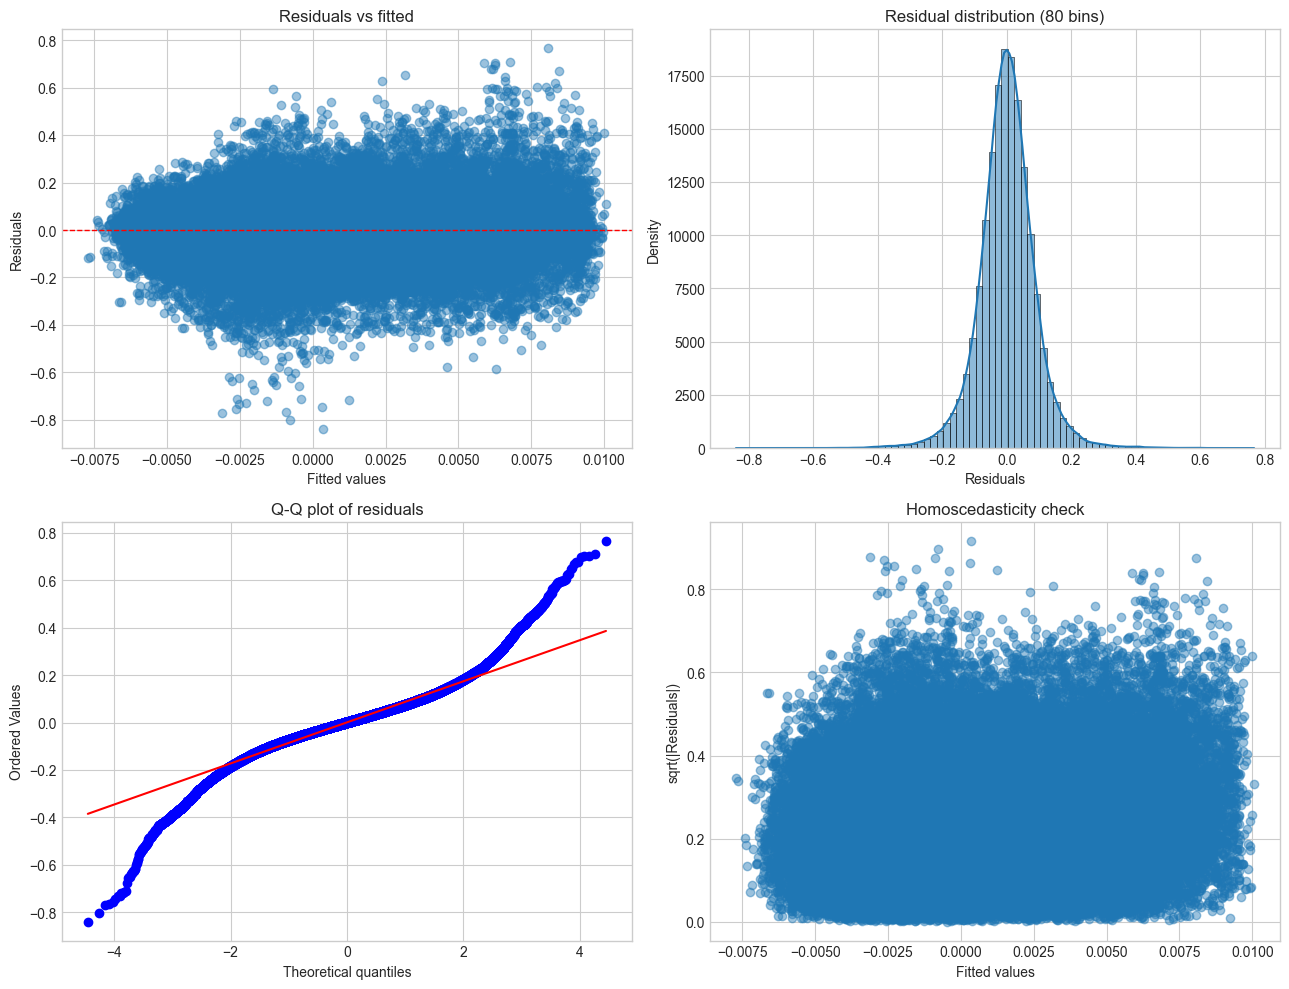

Linear regression assumption study (fit on daily train; eval = daily/overlapping test)
Rows used (regime): 412942
Test-set R^2: 0.0045
Durbin-Watson statistic: 0.1014
Residual skewness: -0.0438
Residual kurtosis: 6.8945
Independence: residuals show autocorrelation (expected — 21-day overlap).


In [2]:
df = build_regression_frame()
study_linear_regression_assumptions(df)


Feature importance = OLS coefficient (fit on daily train; rank features -> [0,1] scale)
  vol_ewm_20         +0.00593
  momentum_12_1      +0.00428
  log_dollar_volume  +0.00403
  momentum_756       +0.00269
  return_1d          -0.00217
  distance_52w_high  -0.00125

Heteroskedasticity tests (daily/overlapping train residuals, n=236,695):
  Breusch-Pagan  LM = 6,478   p = 0.00e+00
  White          LM = 9,378   p = 0.00e+00
  residual Durbin-Watson = 0.10
  -> both reject homoskedasticity, but CAVEAT: residuals are serially
     autocorrelated (DW far from 2 — the 21-day overlap) and cross-sectionally
     clustered, so the tests' iid null is violated and the p-values overstate
     significance. The residual-vs-vol plot is the honest, dependence-robust read.


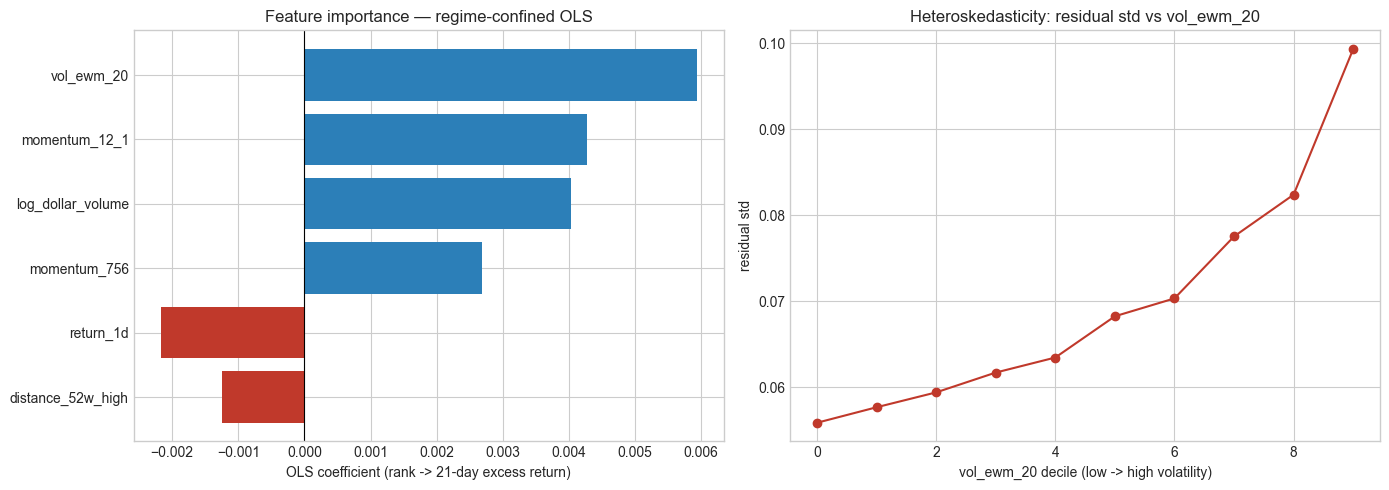

In [3]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, het_white


def feature_importance_and_heteroskedasticity(
    df: pd.DataFrame, feature_cols: list[str] | None = None, resid_stride: int = 1
) -> None:
    """Feature importance + heteroskedasticity, following the headline logic.

    The OLS is ALWAYS fit on the full DAILY train block (the headline beta). Only the
    residuals fed to the tests are optionally subsampled: `resid_stride=21` evaluates
    them on every 21st train date, so they're serially independent (non-overlapping)
    and the Breusch-Pagan / White p-values become trustworthy. The coefficients are
    identical regardless of resid_stride.
    """
    feature_cols = feature_cols or FEATURES
    train_df, _ = regime_split(df)
    X_train = train_df[feature_cols].astype(float)
    y_train = train_df["y"].astype(float)
    model = LinearRegression().fit(X_train, y_train)  # daily fit -> headline beta

    # --- Feature importance -------------------------------------------------
    # Rank-normalized features share a [0,1] scale, so the OLS coefficients ARE the
    # importance. NOTE: these are PARTIAL (multivariate) coefficients, not univariate
    # anomaly signs.
    imp = pd.Series(model.coef_, index=feature_cols).sort_values(key=np.abs)
    print("Feature importance = OLS coefficient (fit on daily train; rank features -> [0,1] scale)")
    for f, c in imp.iloc[::-1].items():
        print(f"  {f:18s} {c:+.5f}")

    # --- Heteroskedasticity: tests on (optionally non-overlapping) residuals -
    sub = _stride_dates(train_df, resid_stride)
    Xs = sub[feature_cols].astype(float)
    resid = np.asarray(sub["y"].astype(float) - model.predict(Xs), dtype=float)
    exog = sm.add_constant(Xs.to_numpy())
    bp_lm, bp_p, _, _ = het_breuschpagan(resid, exog)
    w_lm, w_p, _, _ = het_white(resid, exog)
    dw = float(np.sum(np.diff(resid) ** 2) / np.sum(resid**2))
    label = "non-overlapping train residuals" if resid_stride > 1 else "daily/overlapping train residuals"
    print(f"\nHeteroskedasticity tests ({label}, n={len(resid):,}):")
    print(f"  Breusch-Pagan  LM = {bp_lm:,.0f}   p = {bp_p:.2e}")
    print(f"  White          LM = {w_lm:,.0f}   p = {w_p:.2e}")
    print(f"  residual Durbin-Watson = {dw:.2f}")
    if not (1.5 < dw < 2.5):
        print("  -> both reject homoskedasticity, but CAVEAT: residuals are serially")
        print("     autocorrelated (DW far from 2 — the 21-day overlap) and cross-sectionally")
        print("     clustered, so the tests' iid null is violated and the p-values overstate")
        print("     significance. The residual-vs-vol plot is the honest, dependence-robust read.")
    else:
        print("  -> both reject homoskedasticity. Serial independence holds (DW~2, non-")
        print("     overlapping), so the only remaining iid violation is within-date cross-")
        print("     sectional clustering; these p-values are trustworthy. The residual-vs-vol")
        print("     plot confirms variance scales with volatility.")

    # --- Plots: importance bar + residual variance vs the vol feature -------
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ["#c0392b" if v < 0 else "#2c7fb8" for v in imp.values]
    axes[0].barh(imp.index, imp.values, color=colors)
    axes[0].axvline(0, color="black", linewidth=0.8)
    axes[0].set_xlabel("OLS coefficient (rank -> 21-day excess return)")
    axes[0].set_title("Feature importance — regime-confined OLS")

    dd = pd.DataFrame({"resid": resid, "vol": Xs["vol_ewm_20"].to_numpy()})
    dd["decile"] = pd.qcut(dd["vol"], 10, labels=False, duplicates="drop")
    by = dd.groupby("decile")["resid"].std()
    axes[1].plot(by.index, by.values, marker="o", color="#c0392b")
    axes[1].set_xlabel("vol_ewm_20 decile (low -> high volatility)")
    axes[1].set_ylabel("residual std")
    axes[1].set_title("Heteroskedasticity: residual std vs vol_ewm_20")
    plt.tight_layout()
    plt.show()


feature_importance_and_heteroskedasticity(df)


Univariate IC (standalone signal) vs partial OLS beta (controls for the other 5):

                  univariate_IC partial_beta agree
vol_ewm_20              +0.0250     +0.00593   yes
momentum_12_1           +0.0128     +0.00428   yes
log_dollar_volume       +0.0187     +0.00403   yes
momentum_756            +0.0131     +0.00269   yes
return_1d               -0.0107     -0.00217   yes
distance_52w_high       -0.0042     -0.00125   yes

Sign disagreement (partial sign is a collinearity artifact, not standalone signal): none


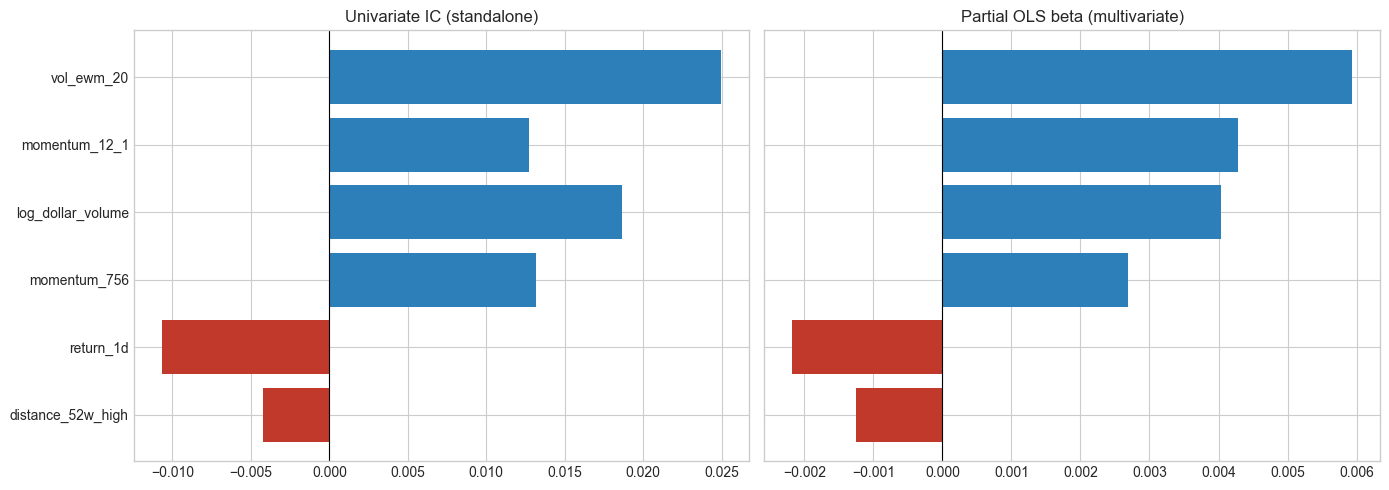

In [6]:
from scipy.stats import spearmanr


def univariate_ic_vs_partial_beta(df: pd.DataFrame, feature_cols: list[str] | None = None) -> None:
    """Disentangle each feature's STANDALONE signal (univariate IC) from its
    MULTIVARIATE OLS coefficient (partial beta), on the regime-confined train block.

    - univariate IC : mean over dates of Spearman(single feature, forward excess return).
                      This is the feature's own predictive sign, ignoring the others.
    - partial beta  : the OLS coefficient — the effect holding the other five fixed.

    If the two SIGNS AGREE, the multivariate coefficient reflects a real marginal
    signal. If they DISAGREE, the partial sign is a collinearity / suppression
    artifact (a correlated feature absorbed the shared signal) — NOT the feature's
    own economics. This is the test for whether distance_52w_high's negative beta is
    genuine mean-reversion (univariate also negative) or a momentum-collinearity
    artifact (univariate positive), and whether vol_ewm_20 / log_dollar_volume are
    genuine regime inversions (both signs agree).
    """
    feature_cols = feature_cols or FEATURES
    train_df, _ = regime_split(df)
    X = train_df[feature_cols].astype(float)
    y = train_df["y"].astype(float)

    beta = pd.Series(LinearRegression().fit(X, y).coef_, index=feature_cols)

    ics: dict[str, list[float]] = {f: [] for f in feature_cols}
    for _, g in train_df.groupby("date"):
        if len(g) < 5:
            continue
        yy = g["y"].to_numpy()
        for f in feature_cols:
            rho = spearmanr(g[f].to_numpy(), yy)[0]
            if np.isfinite(rho):
                ics[f].append(rho)
    uic = pd.Series({f: float(np.mean(v)) for f, v in ics.items()})

    tbl = pd.DataFrame({"univariate_IC": uic, "partial_beta": beta})
    tbl["agree"] = np.sign(tbl["univariate_IC"]) == np.sign(tbl["partial_beta"])
    tbl = tbl.reindex(beta.abs().sort_values(ascending=False).index)

    print("Univariate IC (standalone signal) vs partial OLS beta (controls for the other 5):\n")
    print(
        tbl.to_string(
            formatters={
                "univariate_IC": lambda v: f"{v:+.4f}",
                "partial_beta": lambda v: f"{v:+.5f}",
                "agree": lambda v: "yes" if v else "NO (collinearity)",
            }
        )
    )
    flips = [f for f in tbl.index if not tbl.loc[f, "agree"]]
    print(f"\nSign disagreement (partial sign is a collinearity artifact, not standalone signal): {flips or 'none'}")

    order = list(tbl.index[::-1])
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, col, title in (
        (axes[0], "univariate_IC", "Univariate IC (standalone)"),
        (axes[1], "partial_beta", "Partial OLS beta (multivariate)"),
    ):
        vals = tbl.loc[order, col]
        ax.barh(order, vals.to_numpy(), color=["#c0392b" if v < 0 else "#2c7fb8" for v in vals])
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(title)
    plt.tight_layout()
    plt.show()


univariate_ic_vs_partial_beta(df)


In [7]:
def inspect_residual_outliers(
    df: pd.DataFrame, feature_cols: list[str] | None = None, top_k: int = 25, test_stride: int = 1
) -> pd.DataFrame:
    """Identify and characterize the extreme test residuals.

    `y` is the 21-day EXCESS log return and the fit is tiny (|fitted| < 0.01), so a
    residual is essentially the excess return itself: residual = -2.0 means the stock
    returned ~e^-2 - 1 = -86% RELATIVE to the universe over 21 days (a collapse);
    +1.0 means ~+172% (a moonshot). These are single-name extreme events or data
    glitches. Because of the 21-day OVERLAP, one such move shows up on ~21 consecutive
    daily rows -> the visual "cluster" is usually a handful of episodes replicated.
    """
    feature_cols = feature_cols or FEATURES
    train_df, test_df = regime_split(df)
    test_df = _stride_dates(test_df, test_stride)
    model = LinearRegression().fit(train_df[feature_cols].astype(float), train_df["y"].astype(float))

    out = test_df[["date", "ticker"]].copy()
    if "sector" in test_df.columns:
        out["sector"] = test_df["sector"].to_numpy()
    out["y"] = test_df["y"].to_numpy()
    out["fitted"] = model.predict(test_df[feature_cols].astype(float))
    out["residual"] = out["y"] - out["fitted"]
    out["rel_move_21d"] = np.exp(out["y"]) - 1.0  # implied 21-day return vs the universe

    n_big = int((out["residual"].abs() > 0.5).sum())
    print(f"test_stride={test_stride}:  {len(out):,} test rows, "
          f"{n_big} with |residual| > 0.5 ({n_big / len(out):.2%})\n")

    top = out.reindex(out["residual"].abs().sort_values(ascending=False).index).head(top_k)
    cols = [c for c in ["date", "ticker", "sector", "y", "fitted", "residual", "rel_move_21d"] if c in top.columns]
    print(f"Top {top_k} |residual| outliers:")
    print(top[cols].to_string(index=False, formatters={
        "y": lambda v: f"{v:+.3f}", "fitted": lambda v: f"{v:+.4f}",
        "residual": lambda v: f"{v:+.3f}", "rel_move_21d": lambda v: f"{v:+.0%}",
    }))

    print("\nConcentration — outlier count by ticker (a big count = one event replicated by the overlap):")
    print(top["ticker"].value_counts().head(12).to_string())

    print("\nPer-ticker date span of the outliers (consecutive dates => same 21-day event seen many times):")
    span = top.groupby("ticker")["date"].agg(["min", "max", "count"]).sort_values("count", ascending=False)
    print(span.head(12).to_string())
    return out


_ = inspect_residual_outliers(df, top_k=25, test_stride=1)


test_stride=1:  165,136 test rows, 111 with |residual| > 0.5 (0.07%)

Top 25 |residual| outliers:
      date ticker                 sector      y  fitted residual rel_move_21d
2025-04-15    UNH            Health Care -0.840 +0.0004   -0.840         -57%
2025-04-16    UNH            Health Care -0.804 -0.0008   -0.803         -55%
2025-06-27    CNC                Unknown -0.775 -0.0031   -0.772         -54%
2025-07-01    CNC                Unknown -0.769 -0.0009   -0.768         -54%
2026-03-30   INTC Information Technology +0.774 +0.0081   +0.766        +117%
2025-06-30    CNC                Unknown -0.759 -0.0026   -0.756         -53%
2025-04-11    UNH            Health Care -0.746 +0.0003   -0.746         -53%
2025-06-24    CNC                Unknown -0.736 -0.0025   -0.733         -52%
2025-06-18    CNC                Unknown -0.734 -0.0023   -0.732         -52%
2025-06-26    CNC                Unknown -0.722 -0.0016   -0.720         -51%
2025-04-14    UNH            Health Care -0.

In [8]:
#df